In [2]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

In [3]:
WORKLOADS = ["bc-kron.sg"]

In [4]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""
    
    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"(\d+)MiB", path.name)
    return int(match.group(1)) if match else None

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

In [5]:
dfs = []

for workload in WORKLOADS:
    roots = {
        "arms": Path(f"/users/zimooo2/tiering_solutions/times/arms/{workload}"),
        "model": Path(f"/users/zimooo2/tiering_solutions/times/model/{workload}"),
    }

    records: list[dict] = []
    for label, root in roots.items():
        for path in sorted(root.glob("*.time")):
            if "train" in path.name:
                continue
            metrics = parse_time_file(path)
            try:
                log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
            except FileNotFoundError:
                log_metrics = {}
                
                
            
                
            m = re.search(
                r"_discounted_reward_(\d+)_.*_l2-(true|false)_(\d+)_([0-9]*\.?[0-9]+)\.time$",
                path.name,
            )
            parsed = {}
            if m:
                parsed = {
                    "discounted_reward": int(m.group(1)),
                    "minmax": m.group(2) == "true",
                    "hist_length": int(m.group(3)),
                    "penalty": float(m.group(4)),
                }

            records.append({
                "policy": label,
                "file": path.name,
                "MiB": extract_mib(path),
                **metrics,
                **log_metrics,
                **parsed,
            })

    df = pd.DataFrame(records)
    df["workload"] = workload
    df["id"] = df["discounted_reward"].astype(str) + " " + df["minmax"].astype(str) + " " + df["hist_length"].astype(str) + " " + df["penalty"].astype(str)
    
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
df


arms_df = (
    df.loc[df["policy"] == "arms", ["MiB", "workload", "real"]]
    .rename(columns={"real": "real_arms"})
    .drop_duplicates(subset=["MiB", "workload"])
)

df = (
    df.loc[df["policy"] != "arms"]
    .merge(arms_df, on=["MiB", "workload"], how="left")
)

# >1 means faster than arms, <1 means slower than arms
df["relative_score_vs_arms"] = df["real_arms"] / df["real"]
df

,policy,file,MiB,real,user,sys,discounted_reward,minmax,hist_length,penalty,workload,id,real_arms,relative_score_vs_arms
0,model,1000MiB_run1_model_discounted_reward_90_bc-kro...,1000,633.252,0.733,1.633,90.0,False,4.0,0.8,bc-kron.sg,90.0 False 4.0 0.8,683.993,1.080128
1,model,1000MiB_run1_model_discounted_reward_90_bc-kro...,1000,636.059,0.730,1.724,90.0,False,4.0,0.9,bc-kron.sg,90.0 False 4.0 0.9,683.993,1.075361
2,model,1000MiB_run1_model_discounted_reward_90_bc-kro...,1000,616.701,0.680,1.511,90.0,False,8.0,0.8,bc-kron.sg,90.0 False 8.0 0.8,683.993,1.109116
3,model,1000MiB_run1_model_discounted_reward_90_bc-kro...,1000,629.857,0.710,1.690,90.0,False,8.0,0.9,bc-kron.sg,90.0 False 8.0 0.9,683.993,1.085950
4,model,1000MiB_run1_model_discounted_reward_90_bc-kro...,1000,662.147,0.652,1.611,90.0,True,4.0,0.8,bc-kron.sg,90.0 True 4.0 0.8,683.993,1.032993
5,model,1000MiB_run1_model_discounted_reward_90_bc-kro...,1000,625.754,0.693,1.575,90.0,True,4.0,0.9,bc-kron.sg,90.0 True 4.0 0.9,683.993,1.093070
6,model,1000MiB_run1_model_discounted_reward_90_bc-kro...,1000,614.763,0.659,1.448,90.0,True,8.0,0.8,bc-kron.sg,90.0 True 8.0 0.8,683.993,1.112613
7,model,1000MiB_run1_model_discounted_reward_90_bc-kro...,1000,612.100,0.644,1.477,90.0,True,8.0,0.9,bc-kron.sg,90.0 True 8.0 0.9,683.993,1.117453
8,model,1000MiB_run1_model_discounted_reward_95_bc-kro...,1000,607.315,0.553,1.486,95.0,False,4.0,0.8,bc-kron.sg,95.0 False 4.0 0.8,683.993,1.126257
9,model,1000MiB_run1_model_discounted_reward_95_bc-kro...,1000,639.040,0.702,1.712,95.0,False,4.0,0.9,bc-kron.sg,95.0 False 4.0 0.9,683.993,1.070345


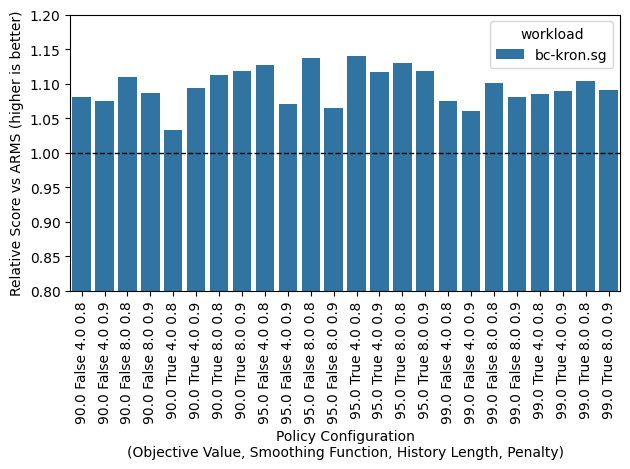

In [6]:
sns.barplot(df[df["MiB"] == 1000], x="id", y="relative_score_vs_arms", hue="workload").set(ylim=(0.8,1.2), ylabel="Relative Score vs ARMS (higher is better)", xlabel="Policy Configuration\n(Objective Value, Smoothing Function, History Length, Penalty)")
import matplotlib.pyplot as plt
plt.axhline(y=1.0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=90)
plt.tight_layout()

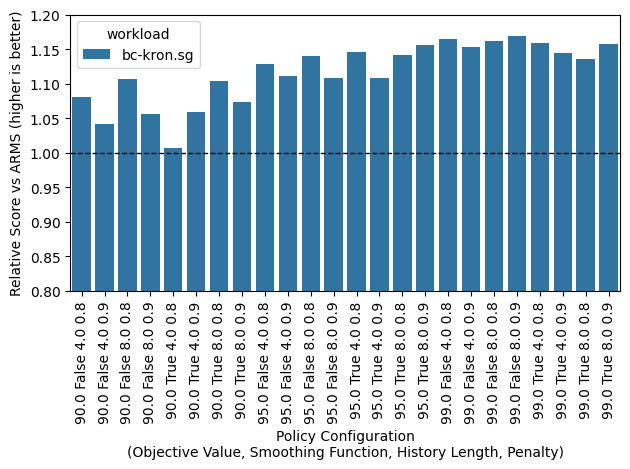

In [7]:
sns.barplot(df[df["MiB"] == 1500], x="id", y="relative_score_vs_arms", hue="workload").set(ylim=(0.8,1.2), ylabel="Relative Score vs ARMS (higher is better)", xlabel="Policy Configuration\n(Objective Value, Smoothing Function, History Length, Penalty)")
import matplotlib.pyplot as plt
plt.axhline(y=1.0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=90)
plt.tight_layout()